# Cryptocurrency Price Prediction and Visualization

This notebook provides interactive visualizations and price predictions using the best model:

1. Load the best model identified from comparison
2. Create interactive visualizations for price prediction
3. Generate next-day price predictions for cryptocurrencies
4. Analyze prediction confidence and trading insights

This notebook leverages the best model to provide actionable insights for cryptocurrency price forecasting.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import ipywidgets as widgets
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

# Set visual style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
warnings.filterwarnings('ignore')

In [ ]:
# Load the best model name
try:
    with open('./models/best_model_name.txt', 'r') as f:
        best_model_name = f.read().strip()
    print(f"Best model: {best_model_name.replace('_', ' ').title()}")
except FileNotFoundError:
    print("Best model name file not found. Using default model.")
    best_model_name = "lightgbm"  # Default to LightGBM if no best model is saved

# Function to load a model
def load_model(model_name):
    """
    Load a trained model and its metadata
    
    Parameters:
        model_name: Name of the model to load
        
    Returns:
        tuple: (model, metadata)
    """
    model_filename = f'./models/{model_name}_model.pkl'
    metadata_filename = f'./models/{model_name}_metadata.pkl'
    
    # Load the model
    try:
        with open(model_filename, 'rb') as f:
            model = pickle.load(f)
            
        # Load the metadata
        with open(metadata_filename, 'rb') as f:
            metadata = pickle.load(f)
            
        return model, metadata
    except Exception as e:
        print(f"Error loading model {model_name}: {e}")
        return None, None

# Load the best model
best_model, model_metadata = load_model(best_model_name)

if best_model is None:
    raise ValueError("Failed to load the best model")

print(f"Model loaded: {model_metadata['name']}")
print(f"Features: {len(model_metadata['features'])}")

# Handle special models like ElasticNet that need a scaler
if 'requires_scaling' in model_metadata and model_metadata['requires_scaling']:
    print("This model requires feature scaling")
    scaler_filename = f'./models/{best_model_name}_scaler.pkl'
    with open(scaler_filename, 'rb') as f:
        scaler = pickle.load(f)
    print("Feature scaler loaded")

# For LSTM, make sure we have the model object
if best_model_name == 'lstm':
    print("LSTM model detected")
    print(f"Sequence length: {best_model.sequence_length}")
    
    # Ensure model is loaded
    if hasattr(best_model, 'model') and best_model.model is None:
        print("Loading LSTM model weights...")
        # Trigger model creation with a dummy prediction
        dummy_X = np.zeros((best_model.sequence_length, len(model_metadata['features'])))
        dummy_X = dummy_X.reshape(1, best_model.sequence_length, len(model_metadata['features']))
        best_model.model.predict(dummy_X, verbose=0)
        print("LSTM model ready")

Best model: Lightgbm
Model loaded: LightGBM
Features: 13


In [ ]:
# Load the original data to get list of cryptocurrencies
df = pd.read_csv('./data/crypto_cleaned.csv', parse_dates=['date'])
symbols = sorted(df['symbol'].unique())
print(f"Dataset contains {len(symbols)} unique cryptocurrencies")

# Function to prepare data for a specific cryptocurrency
def prepare_data(symbol):
    """
    Prepare data for a specific cryptocurrency symbol
    
    Parameters:
        symbol: Cryptocurrency symbol
        
    Returns:
        DataFrame with processed features
    """
    # Filter data for the selected symbol
    symbol_df = df[df['symbol'] == symbol].copy().sort_values('date')
    
    if len(symbol_df) < 20:  # Need enough data for feature engineering
        print(f"Not enough data for {symbol}. Need at least 20 days.")
        return None
    
    # Feature engineering (same as in Data Preparation notebook)
    symbol_df['spread'] = symbol_df['high'] - symbol_df['low']
    symbol_df['return'] = (symbol_df['close'] - symbol_df['open']) / symbol_df['open']
    symbol_df['ma_3'] = symbol_df['close'].rolling(window=3).mean()
    symbol_df['ma_7'] = symbol_df['close'].rolling(window=7).mean()
    symbol_df['ma_14'] = symbol_df['close'].rolling(window=14).mean()
    symbol_df['volatility_7'] = symbol_df['close'].rolling(window=7).std()
    symbol_df['close_lag1'] = symbol_df['close'].shift(1)
    symbol_df['volume_lag1'] = symbol_df['volume'].shift(1)
    
    # Target: next day's close price
    symbol_df['target'] = symbol_df['close'].shift(-1)
    
    # Drop rows with NaN values
    symbol_df = symbol_df.dropna()
    
    return symbol_df

Dataset contains 1716 unique cryptocurrencies


## Interactive Cryptocurrency Price Prediction

This section provides an interactive visualization tool for exploring cryptocurrency price predictions.

In [4]:
# Function to create visualization for a cryptocurrency
def visualize_crypto(symbol, lookback_days=90, future_days=30):
    """
    Visualize price predictions for a cryptocurrency
    
    Parameters:
        symbol: Cryptocurrency symbol
        lookback_days: Number of historical days to display
        future_days: Number of days to predict into the future
    """
    # Prepare data
    symbol_df = prepare_data(symbol)
    
    if symbol_df is None or len(symbol_df) < lookback_days:
        print(f"Not enough data for {symbol}")
        return
    
    # Extract features for prediction
    features = model_metadata['features']
    X = symbol_df[features]
    
    # Make predictions
    if best_model_name == 'elasticnet':
        # Scale features for ElasticNet
        X_scaled = scaler.transform(X)
        predictions = best_model.predict(X_scaled)
    else:
        predictions = best_model.predict(X)
    
    # Calculate metrics
    y_true = symbol_df['target']
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)
    
    # Create plot
    plt.figure(figsize=(14, 8))
    
    # Get recent data for display
    recent_df = symbol_df.iloc[-lookback_days:].copy()
    recent_dates = recent_df['date']
    recent_prices = recent_df['close']
    recent_preds = predictions[-lookback_days:]
    
    # Plot historical prices and predictions
    plt.plot(recent_dates, recent_prices, 'b-', linewidth=2, label='Actual Price')
    plt.plot(recent_dates, recent_preds, 'r--', linewidth=2, label='Predicted Price')
    
    # Add confidence interval based on MAE
    plt.fill_between(
        recent_dates,
        recent_preds - mae,
        recent_preds + mae,
        color='red',
        alpha=0.2,
        label=f'±MAE (${mae:.2f})'
    )
    
    # Predict future prices if we have enough data
    if len(recent_df) > 0 and future_days > 0:
        # Get last row for initial prediction
        last_row = symbol_df.iloc[-1:][features]
        future_dates = pd.date_range(
            start=recent_df['date'].iloc[-1] + pd.Timedelta(days=1),
            periods=future_days,
            freq='D'
        )
        
        # Arrays to store future predictions
        future_preds = np.zeros(future_days)
        upper_bound = np.zeros(future_days)
        lower_bound = np.zeros(future_days)
        
        # First prediction
        if best_model_name == 'elasticnet':
            future_preds[0] = best_model.predict(scaler.transform(last_row))[0]
        else:
            future_preds[0] = best_model.predict(last_row)[0]
            
        upper_bound[0] = future_preds[0] + mae
        lower_bound[0] = future_preds[0] - mae
        
        # For each future day, use the previous prediction to generate features
        for i in range(1, future_days):
            # Create a copy of the last row to update
            next_features = last_row.copy()
            
            # Update close price based on previous prediction
            next_features.iloc[0, features.index('close')] = future_preds[i-1]
            
            # Simple update of other features (in a real scenario, this would be more sophisticated)
            if 'close_lag1' in features:
                next_features.iloc[0, features.index('close_lag1')] = future_preds[i-1]
            
            # Make next prediction
            if best_model_name == 'elasticnet':
                future_preds[i] = best_model.predict(scaler.transform(next_features))[0]
            else:
                future_preds[i] = best_model.predict(next_features)[0]
                
            upper_bound[i] = future_preds[i] + mae * np.sqrt(i+1)  # Increase uncertainty over time
            lower_bound[i] = future_preds[i] - mae * np.sqrt(i+1)
            
        # Plot future predictions with increasing uncertainty
        plt.plot(future_dates, future_preds, 'r-.', linewidth=2, label='Future Predictions')
        plt.fill_between(
            future_dates,
            lower_bound,
            upper_bound,
            color='red',
            alpha=0.1,
            label='Future Uncertainty'
        )
        
        # Add vertical line to separate historical and future data
        plt.axvline(x=recent_dates.iloc[-1], color='k', linestyle='--', alpha=0.3)
        plt.text(
            recent_dates.iloc[-1], 
            plt.ylim()[1]*0.9, 
            'Future', 
            ha='left', 
            va='top', 
            rotation=90, 
            alpha=0.5
        )
    
    # Add title and labels
    plt.title(f'{symbol} Price Prediction using {model_metadata["name"]}', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price ($)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Format x-axis dates
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()
    
    # Print performance metrics
    print(f"\nPerformance Metrics for {symbol}:")
    print(f"Mean Absolute Error (MAE): ${mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:.4f}")
    print(f"R² Score: {r2:.4f}")
    
    # Next day prediction
    last_price = recent_prices.iloc[-1]
    next_day_pred = future_preds[0] if future_days > 0 else np.nan
    
    if not np.isnan(next_day_pred):
        change_pct = ((next_day_pred - last_price) / last_price) * 100
        direction = "Up" if next_day_pred > last_price else "Down"
        
        print(f"\nNext-Day Prediction:")
        print(f"Last Price: ${last_price:.4f} (on {recent_dates.iloc[-1].strftime('%Y-%m-%d')})")
        print(f"Predicted Next Price: ${next_day_pred:.4f}")
        print(f"Predicted Change: {change_pct:.2f}% ({direction})")
        print(f"Prediction Confidence Interval: ${next_day_pred - mae:.4f} to ${next_day_pred + mae:.4f}")

# Create interactive widgets
symbol_dropdown = widgets.Dropdown(
    options=symbols,
    description='Symbol:',
    style={'description_width': 'initial'}
)

lookback_slider = widgets.IntSlider(
    value=90,
    min=30,
    max=365,
    step=30,
    description='History (days):',
    style={'description_width': 'initial'}
)

future_slider = widgets.IntSlider(
    value=30,
    min=0,
    max=90,
    step=5,
    description='Future (days):',
    style={'description_width': 'initial'}
)

button = widgets.Button(
    description='Generate Prediction',
    button_style='primary',
    tooltip='Click to generate prediction visualization'
)

output = widgets.Output()

# Function to handle button click
def on_button_click(b):
    with output:
        output.clear_output()
        visualize_crypto(
            symbol_dropdown.value,
            lookback_slider.value,
            future_slider.value
        )

# Connect button to function
button.on_click(on_button_click)

# Display widgets
print("Select a cryptocurrency and parameters for prediction:")
display(widgets.VBox([
    symbol_dropdown, 
    lookback_slider,
    future_slider,
    button,
    output
]))

Select a cryptocurrency and parameters for prediction:


## Next-Day Price Predictions

This section generates and displays the next-day price predictions for the top cryptocurrencies.

,Symbol,Last Date,Last Price ($),Predicted Next Price ($),Change (%),Direction,MAE ($)
3,1337,2018-11-28,$0.0000,$54.6508,176292786.46%,Up,$66.8662
0,$$$,2018-11-28,$0.0004,$47.9825,11702948.94%,Up,$56.7664
1,$PAC,2018-11-28,$0.0010,$118.3867,11372301.03%,Up,$205.4794
6,2GIVE,2018-11-28,$0.0019,$70.8366,3722264.82%,Up,$113.7221
2,0XBTC,2018-11-28,$0.4180,$3132.1998,749167.35%,Up,$2215.6149
4,1ST,2018-11-28,$0.0378,$119.7831,316426.40%,Up,$2029.8821
5,1WO,2018-11-28,$0.0850,$225.3433,265044.11%,Up,$276.0876
8,42,2018-11-29,$23217.9400,$103.6926,-99.55%,Down,$12599.5449
7,300,2018-11-28,$148.1800,$60.4364,-59.21%,Down,$346.5854


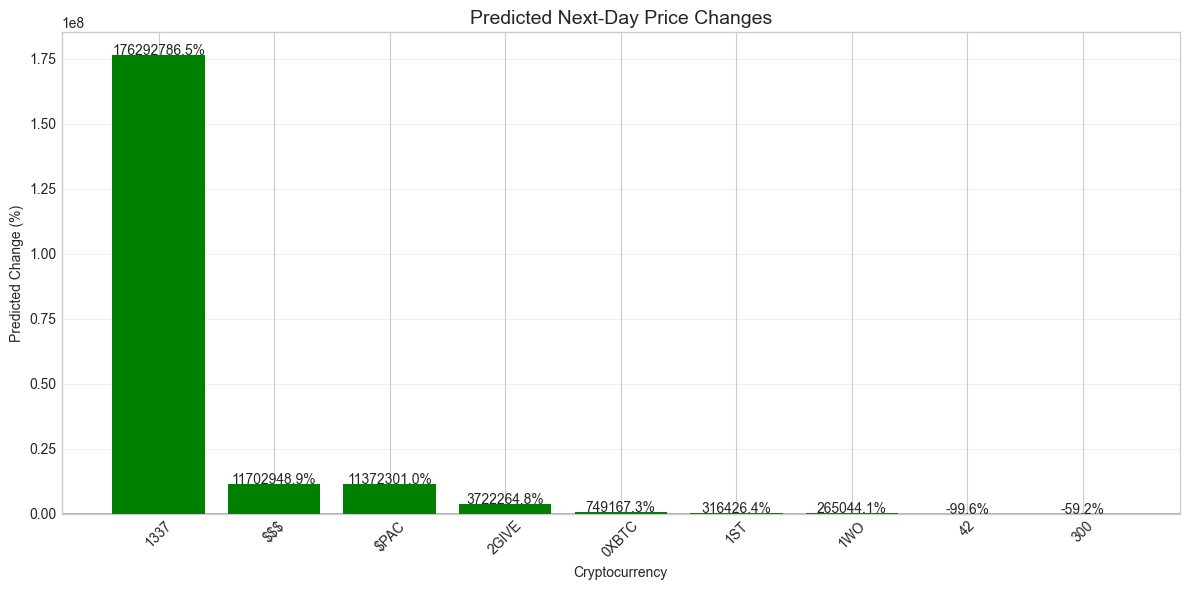

In [5]:
# Function to get next-day prediction for a cryptocurrency
def predict_next_day(symbol):
    """
    Predict the next-day price for a cryptocurrency
    
    Parameters:
        symbol: Cryptocurrency symbol
        
    Returns:
        dict with prediction info or None if error
    """
    # Prepare data
    symbol_df = prepare_data(symbol)
    
    if symbol_df is None or len(symbol_df) < 20:
        return None
    
    # Get latest data point
    latest_row = symbol_df.iloc[-1:][model_metadata['features']]
    latest_date = symbol_df['date'].iloc[-1]
    latest_price = symbol_df['close'].iloc[-1]
    
    # Make prediction
    if best_model_name == 'elasticnet':
        # Scale features for ElasticNet
        latest_scaled = scaler.transform(latest_row)
        prediction = best_model.predict(latest_scaled)[0]
    else:
        prediction = best_model.predict(latest_row)[0]
    
    # Calculate metrics on all available data
    X = symbol_df[model_metadata['features']]
    y = symbol_df['target']
    
    if best_model_name == 'elasticnet':
        all_preds = best_model.predict(scaler.transform(X))
    else:
        all_preds = best_model.predict(X)
    
    mae = mean_absolute_error(y, all_preds)
    rmse = np.sqrt(mean_squared_error(y, all_preds))
    
    # Calculate prediction statistics
    change = prediction - latest_price
    change_pct = (change / latest_price) * 100
    direction = "Up" if change > 0 else "Down"
    confidence_interval = (prediction - mae, prediction + mae)
    
    return {
        'symbol': symbol,
        'latest_date': latest_date,
        'latest_price': latest_price,
        'prediction': prediction,
        'change': change,
        'change_pct': change_pct,
        'direction': direction,
        'mae': mae,
        'rmse': rmse,
        'confidence_low': confidence_interval[0],
        'confidence_high': confidence_interval[1]
    }

# Generate predictions for top 10 cryptocurrencies (or all if less than 10)
top_symbols = symbols[:min(10, len(symbols))]
predictions = []

for symbol in top_symbols:
    result = predict_next_day(symbol)
    if result is not None:
        predictions.append(result)

# Convert to DataFrame for display
if predictions:
    pred_df = pd.DataFrame(predictions)
    
    # Format and display the predictions
    pred_df['latest_date'] = pred_df['latest_date'].dt.strftime('%Y-%m-%d')
    
    # Create a styled DataFrame for display
    styled_df = pred_df[['symbol', 'latest_date', 'latest_price', 'prediction', 
                         'change_pct', 'direction', 'mae']].copy()
    
    styled_df.columns = ['Symbol', 'Last Date', 'Last Price ($)', 'Predicted Next Price ($)', 
                         'Change (%)', 'Direction', 'MAE ($)']
    
    # Sort by absolute change percentage to show biggest movers first
    styled_df = styled_df.sort_values(by='Change (%)', key=abs, ascending=False)
    
    # Format for display
    display(styled_df.style
            .format({
                'Last Price ($)': '${:.4f}',
                'Predicted Next Price ($)': '${:.4f}',
                'Change (%)': '{:.2f}%',
                'MAE ($)': '${:.4f}'
            })
            .bar(subset=['Change (%)'], color=['red', 'green'])
           )
    
    # Create a visual of the predictions
    plt.figure(figsize=(12, 6))
    
    # Create a bar chart of predicted price changes
    colors = ['green' if x > 0 else 'red' for x in styled_df['Change (%)']]
    plt.bar(styled_df['Symbol'], styled_df['Change (%)'], color=colors)
    
    plt.title('Predicted Next-Day Price Changes', fontsize=14)
    plt.xlabel('Cryptocurrency')
    plt.ylabel('Predicted Change (%)')
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45)
    
    # Add value labels on top of bars
    for i, v in enumerate(styled_df['Change (%)']):
        plt.text(i, v + (0.5 if v >= 0 else -1.5), f"{v:.1f}%", ha='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid predictions available")

Trading Recommendations:


,Symbol,Current Price ($),Predicted Price ($),Change (%),Signal,Confidence,MAE ($)
2,0XBTC,$0.4180,$3132.1998,749167.35%,Strong Buy,1.41,$2215.6149
0,$$$,$0.0004,$47.9825,11702948.94%,Buy,0.85,$56.7664
3,1337,$0.0000,$54.6508,176292786.46%,Buy,0.82,$66.8662
5,1WO,$0.0850,$225.3433,265044.11%,Buy,0.82,$276.0876
6,2GIVE,$0.0019,$70.8366,3722264.82%,Buy,0.62,$113.7221
1,$PAC,$0.0010,$118.3867,11372301.03%,Buy,0.58,$205.4794
4,1ST,$0.0378,$119.7831,316426.40%,Buy,0.06,$2029.8821
7,300,$148.1800,$60.4364,-59.21%,Sell,0.25,$346.5854
8,42,$23217.9400,$103.6926,-99.55%,Strong Sell,1.83,$12599.5449


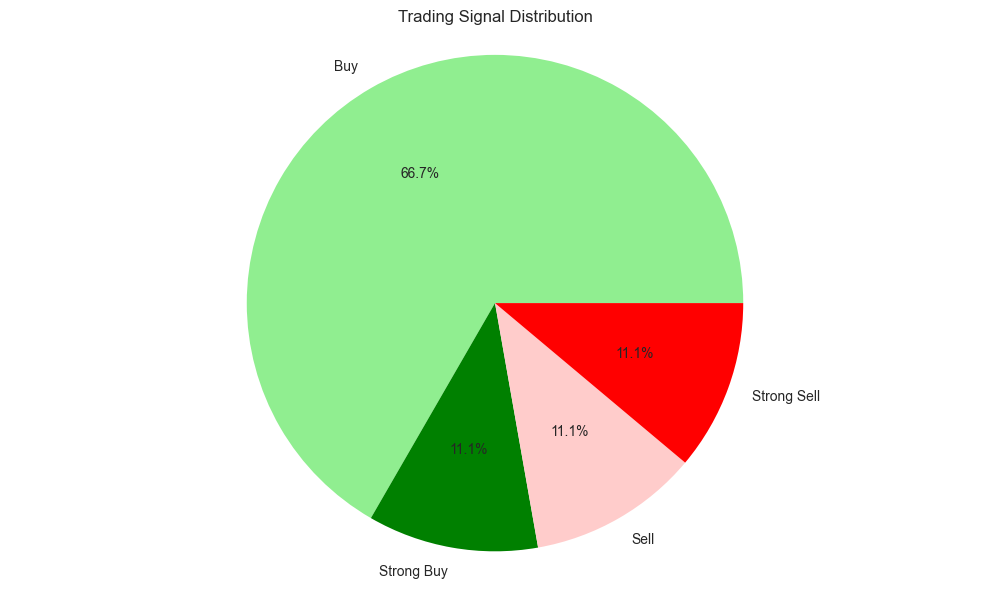

In [6]:
# Create a trading recommendation system based on predictions
if predictions:
    # Create a copy of the predictions DataFrame for trading analysis
    trading_df = pred_df.copy()
    
    # Define confidence level - how many times the MAE we use for determining confidence
    confidence_factor = 1.0
    
    # Add trading signals
    trading_df['signal'] = 'Hold'
    
    # Strong buy: predicted increase > MAE * confidence_factor
    trading_df.loc[trading_df['change'] > trading_df['mae'] * confidence_factor, 'signal'] = 'Strong Buy'
    
    # Buy: predicted increase > 0 but not strong
    trading_df.loc[(trading_df['change'] > 0) & 
                   (trading_df['change'] <= trading_df['mae'] * confidence_factor), 
                   'signal'] = 'Buy'
    
    # Strong sell: predicted decrease > MAE * confidence_factor
    trading_df.loc[trading_df['change'] < -trading_df['mae'] * confidence_factor, 'signal'] = 'Strong Sell'
    
    # Sell: predicted decrease < 0 but not strong
    trading_df.loc[(trading_df['change'] < 0) & 
                    (trading_df['change'] >= -trading_df['mae'] * confidence_factor), 
                    'signal'] = 'Sell'
    
    # Calculate signal strength (ratio of change to MAE)
    trading_df['signal_strength'] = abs(trading_df['change'] / trading_df['mae'])
    
    # Display trading recommendations
    display_cols = ['symbol', 'latest_price', 'prediction', 'change_pct', 
                    'signal', 'signal_strength', 'mae']
    display_df = trading_df[display_cols].copy()
    
    # Sort by signal and then by signal strength
    signal_order = {'Strong Buy': 0, 'Buy': 1, 'Hold': 2, 'Sell': 3, 'Strong Sell': 4}
    display_df['signal_rank'] = display_df['signal'].map(signal_order)
    display_df = display_df.sort_values(['signal_rank', 'signal_strength'], 
                                        ascending=[True, False]).drop('signal_rank', axis=1)
    
    # Rename columns for display
    display_df.columns = ['Symbol', 'Current Price ($)', 'Predicted Price ($)', 
                          'Change (%)', 'Signal', 'Confidence', 'MAE ($)']
    
    # Format for display
    styled_trading = display_df.style.format({
        'Current Price ($)': '${:.4f}',
        'Predicted Price ($)': '${:.4f}',
        'Change (%)': '{:.2f}%',
        'Confidence': '{:.2f}',
        'MAE ($)': '${:.4f}'
    })
    
    # Add color to signals
    def signal_color(val):
        if val == 'Strong Buy':
            return 'background-color: green; color: white'
        elif val == 'Buy':
            return 'background-color: lightgreen'
        elif val == 'Strong Sell':
            return 'background-color: red; color: white'
        elif val == 'Sell':
            return 'background-color: #FFCCCB'  # Light red
        else:
            return 'background-color: #F5F5F5'  # Light gray
    
    styled_trading = styled_trading.applymap(signal_color, subset=['Signal'])
    
    print("Trading Recommendations:")
    display(styled_trading)
    
    # Create a visual of the trading recommendations
    plt.figure(figsize=(10, 6))
    
    # Count signals
    signal_counts = display_df['Signal'].value_counts()
    
    # Create pie chart
    colors = {
        'Strong Buy': 'green',
        'Buy': 'lightgreen',
        'Hold': 'gray',
        'Sell': '#FFCCCB',
        'Strong Sell': 'red'
    }
    
    # Get only the signals that exist in our data
    available_signals = [s for s in signal_order.keys() if s in signal_counts.index]
    signal_values = [signal_counts[s] if s in signal_counts.index else 0 for s in available_signals]
    signal_colors = [colors[s] for s in available_signals if s in signal_counts.index]
    
    plt.pie(signal_counts, labels=signal_counts.index, autopct='%1.1f%%', 
            colors=[colors[s] for s in signal_counts.index])
    plt.title('Trading Signal Distribution')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()